# Load Dataset

In [62]:
# Import necessary packages
from utils import *
import numpy as np
import cmasher as cmr
import matplotlib.pyplot as plt 
from tqdm import tqdm 
from pathlib import Path
from scipy.spatial.distance import squareform, pdist

In [63]:
# Import the data

# Define path to the simulation folder
simulation_fpath = Path(r'F:\Tee\LiveCellSimulation\Dataset\20251121_LiveCellSimulation')

# List all subfolders (all datasets) inside this folder
simulation_folders = list(simulation_fpath.glob('*'))

In [64]:
# Show all the subfolders
simulation_folders

[WindowsPath('F:/Tee/LiveCellSimulation/Dataset/20251121_LiveCellSimulation/CrumpledExtrusionTest'),
 WindowsPath('F:/Tee/LiveCellSimulation/Dataset/20251121_LiveCellSimulation/CrumpledNoExtrusionTest'),
 WindowsPath('F:/Tee/LiveCellSimulation/Dataset/20251121_LiveCellSimulation/RouseTest')]

In [65]:
# Load the dataset onto RAM using `load_simulation` helper function

# Dataset is now in a dictionary whose keys are the names of corresponding subfolders
simulation_dataset = {
    d.name: load_simulation(d) for d in simulation_folders
} 

Loading 6 replicates...
Loading in parallel...
Success...
Loading 10 replicates...
Loading in parallel...
Success...
Loading 10 replicates...
Loading in parallel...
Success...


In [20]:
# List all the dataset's names
list(simulation_dataset.keys()) 

['CrumpledExtrusionTest', 'CrumpledNoExtrusionTest', 'RouseTest']

## Dimension of the data structures accomodate polymer data

In [21]:
# Show the data structure of the polymer realizations
for curr_dataset_name, curr_dataset in simulation_dataset.items():
    curr_polys = curr_dataset['polys']
    num_replicates, num_timepoints, num_monomers, _ = curr_polys.shape
    print(f'{curr_dataset_name} contains {num_replicates} independent trajectories. Each trajectory has {num_timepoints} MD frames with {num_monomers} monomers.')

CrumpledExtrusionTest contains 6 independent trajectories. Each trajectory has 10001 MD frames with 10000 monomers.
CrumpledNoExtrusionTest contains 10 independent trajectories. Each trajectory has 10001 MD frames with 10000 monomers.
RouseTest contains 10 independent trajectories. Each trajectory has 10001 MD frames with 10000 monomers.


## Example: show the evolution of the distance maps as a function of time 

In [22]:
# Example: show the distance map of one trajectory as a function of time 
curr_dataset_name = 'RouseTest'
curr_dataset = simulation_dataset[curr_dataset_name]
curr_polys = curr_dataset['polys']

idx_replicate = 0
subsampling_ratio = 10  # subsampling the polymer every 10 monomer due to memory and plotting constraints

# remember dimension = (num_replicates x num_timepoints x num_monomers x 3 xyz)
curr_trajectory = curr_polys[idx_replicate, :, ::subsampling_ratio, :]

# Calculate distance maps
# Iterate through different timepoints
curr_dmaps = [squareform(pdist(x)) for x in tqdm(curr_trajectory)]

100%|████████████████████████████████████████████████████████████████████████████| 10001/10001 [01:50<00:00, 90.53it/s]


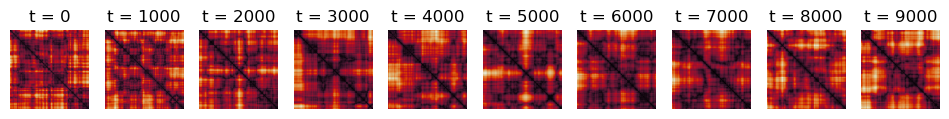

In [23]:
# Plot the distance map as a function of time 
fig, axs = plt.subplots(1, 10, figsize=(12, 3))
for idx_ax in range(10):
    ax = axs[idx_ax]
    curr_dmap = curr_dmaps[idx_ax * 1000]
    ax.imshow(curr_dmap, cmap=cmr.sunburst)
    ax.axis('off')
    ax.set_title(f't = {idx_ax * 1000}')

## Validation: Calculate MSCD and compare it to the polymer theory

In [61]:
# Define helper functions for calculating numba
from numba import njit, prange
from joblib import Parallel, delayed


@njit(parallel=True)
def calculate_MSCD_numba(poly, point1, point2):
    """
    poly:  (n_frames, n_monomers, dim)
    point1, point2: monomer indices

    Returns:
        MSCD array of length (n_frames - 2),
        same semantics as your original calculate_MSCD.
    """
    n_frames = poly.shape[0]
    dim = poly.shape[2]
                                       
    # Compute distance time series between the two points
    dist_array = np.empty(n_frames, dtype=np.float64)
    for t in range(n_frames):
        s = 0.0
        for d in range(dim):
            diff = poly[t, point1, d] - poly[t, point2, d]
            s += diff * diff
        dist_array[t] = np.sqrt(s)

    # MSCD for lag tau = 1 .. n_frames-2
    mscd = np.empty(n_frames - 2, dtype=np.float64)
    for tau_idx in prange(n_frames - 2):
        tau = tau_idx + 1
        s2 = 0.0
        count = 0
        i = 0
        while i + tau < n_frames:
            diff = dist_array[i] - dist_array[i + tau]
            s2 += diff * diff
            count += 1
            i += tau
        mscd[tau_idx] = s2 / count

    return mscd


@njit(parallel=True)
def calculate_Rg_numba(polys, point1, point2):
    """
    polys: (n_frames, n_monomers, dim)

    Returns:
        Scalar Rg, same definition as your original calculate_Rg:
        mean over frames and monomers of squared distance from
        per-frame centroid.
    """
    n_frames, n_monomers, dim = polys.shape
    seg_len = point2 - point1

    total = 0.0

    for t in prange(n_frames):
        # centroid for this frame (for the interval [point1:point2])
        centroid = np.zeros(dim, dtype=np.float64)
        for j in range(point1, point2):
            for d in range(dim):
                centroid[d] += polys[t, j, d]
        for d in range(dim):
            centroid[d] /= seg_len

        # sum squared distances to centroid
        for j in range(point1, point2):
            s = 0.0
            for d in range(dim):
                diff = polys[t, j, d] - centroid[d]
                s += diff * diff
            total += s

    # mean over all frames and all monomers in the segment
    return total / (n_frames * seg_len)


def make_start_monomer_list(interval, n_monomers=10000):
    step = n_monomers - interval // 1000
    return list(range(0, n_monomers - interval, step))

def process_interval(interval, poly):
    """
    Compute MSCD and Rg lists for both simulations for one interval.
    Uses Numba-accelerated kernels.
    """
    start_monomer_list = make_start_monomer_list(interval)

    mscd_list = []
    rg_list = []


    for start in start_monomer_list:
        end = start + interval

        # Numba versions
        mscd = calculate_MSCD_numba(poly, start, end)
        mscd_list.append(mscd)

        rg = calculate_Rg_numba(poly, start, end)
        rg_list.append(rg)

    return mscd_list, rg_list

In [25]:
# Define genomic intervals that we are interested in
intervals = [10, 20, 50, 70, 100, 500, 700, 1000, 5000, 7000]

In [26]:
# Find MSCD in all datasets
livecell_analysis_dataset = {}
for condition_name, curr_dataset in simulation_dataset.items():
    curr_polys = curr_dataset['polys']
    mscd_all = []
    rg_all = []
    num_replicates = curr_polys.shape[0]


    for idx_replicate in tqdm(range(num_replicates)):
        curr_poly = curr_polys[idx_replicate]
        # Parallel over intervals
        results = Parallel(n_jobs=-1, backend="loky")(
            delayed(process_interval)(interval, curr_poly)
            for interval in tqdm(intervals)
        )
        curr_mscd = [x[0][0] for x in results]
        curr_rg = [x[1][0] for x in results]
        
        mscd_all.append(curr_mscd)
        rg_all.append(curr_rg)
    
    mscd_all = np.array(mscd_all)
    rg_all = np.array(rg_all)

    mscd_mean = np.mean(mscd_all, axis=0)
    rg_mean = np.mean(rg_all, axis=0)

    livecell_analysis_dataset[condition_name] = {
        'mscd_all': mscd_all,
        'mscd_mean': mscd_mean,
        'rg_all': rg_all,
        'rg_mean': rg_mean
    }

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:31<00:00,  3.19s/it]


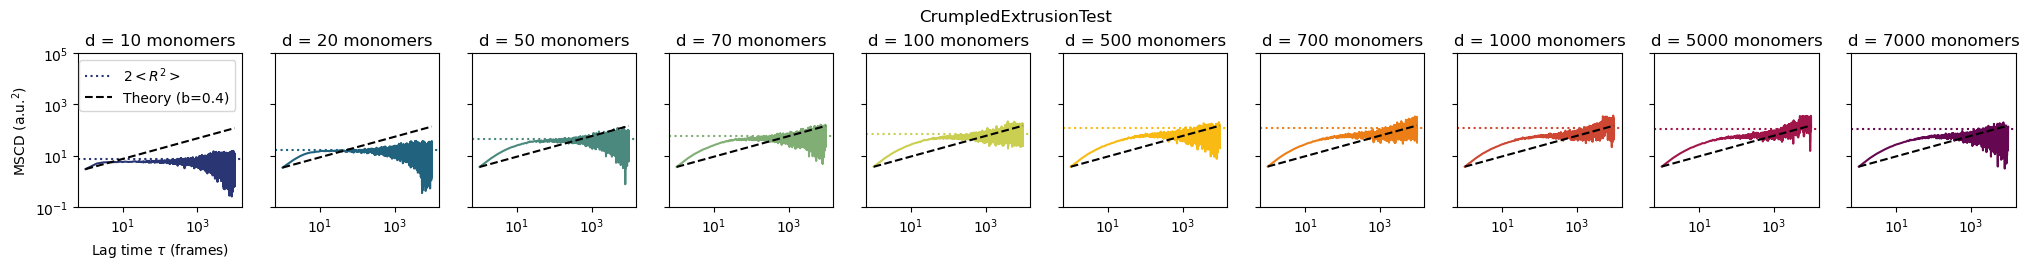

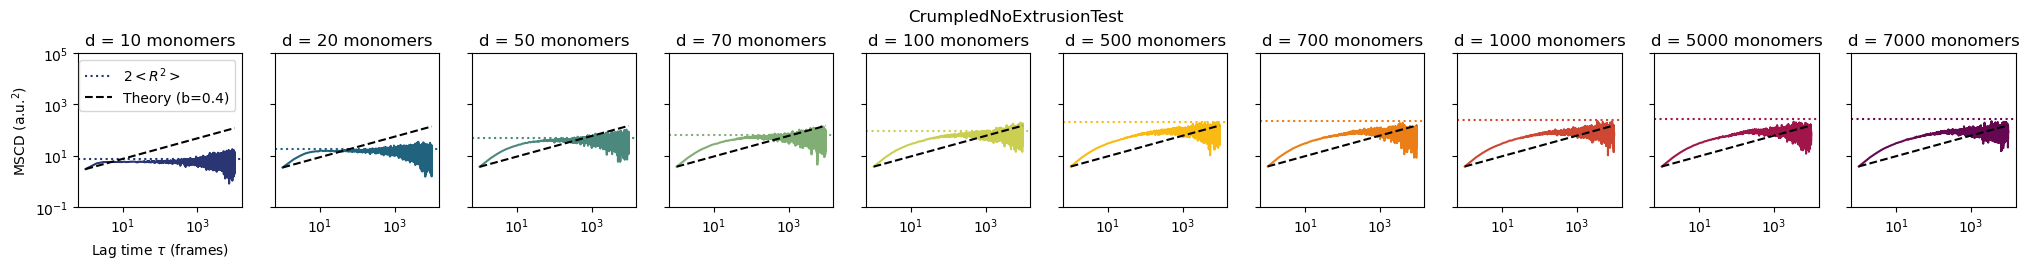

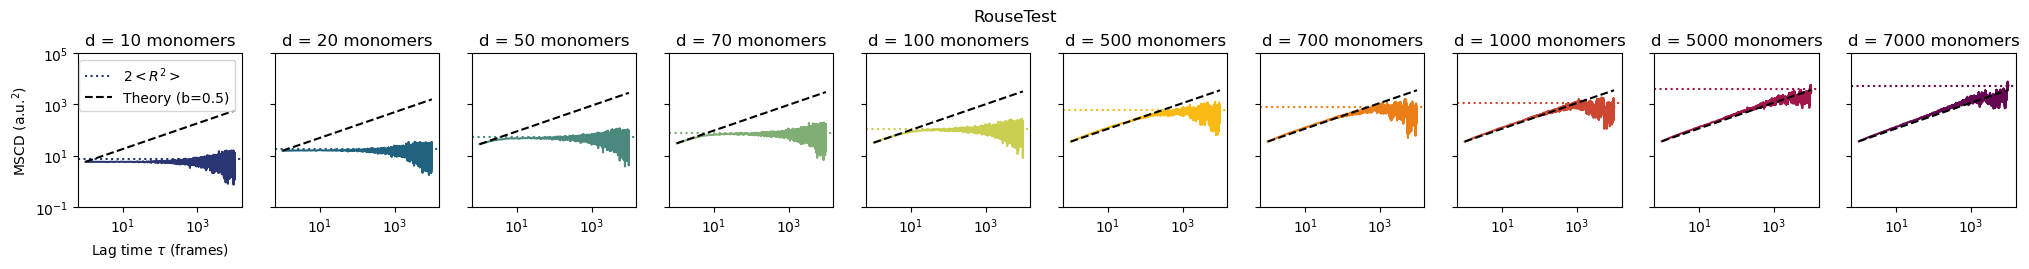

In [27]:
# Plot all the MSCD across all datasets at different genomic distance
for condition_name, livecell_analysis in livecell_analysis_dataset.items():
    exponent = 0.5 if condition_name == 'RouseTest' else 0.4
    colors = cmr.take_cmap_colors('cmr.pride', len(intervals), cmap_range=(0.1, 0.9))
    fig, axs = plt.subplots(1, len(intervals), figsize=(len(intervals)*2.5, 2), sharex=True, sharey=True)
    mscd_mean = livecell_analysis['mscd_mean']
    rg_mean = livecell_analysis['rg_mean']
    for idx_interval in range(len(results)):
        ax = axs[idx_interval]

        curr_mscd = mscd_mean[idx_interval]
        curr_rg = rg_mean[idx_interval]
        ax.loglog(np.arange(1, len(curr_mscd)+1), curr_mscd, color=colors[idx_interval])
        ax.axhline(2*curr_rg, color=colors[idx_interval], ls='dotted', label=r'2$<R^2>$')
        
        # Determine x-range from your data
        max_len = max(len(r[0][0]) for r in results)
        x_ref = np.arange(1, max_len+1)

        # Choose a prefactor near your data (e.g., match first MSCD of first trace)
        C = curr_mscd[0] / (1**exponent)

        ax.loglog(x_ref, C * x_ref**exponent, 'k--', label=f'Theory (b={exponent})')
        ax.set_ylim([1e-1, 1e5])
        ax.set_title(f'd = {intervals[idx_interval]} monomers')
        
    axs[0].set_xlabel(r'Lag time $\tau$ (frames)')
    axs[0].set_ylabel(r'MSCD (a.u.$^2$)')
    axs[0].legend()
    fig.suptitle(condition_name, y=1.1)
    plt.show()

## Accesing bound cohesin positions in the simulation

In [35]:
# Example: Accessing cohesin location on the polymer 

# Choose the dataset that has cohesins
curr_dataset_name = 'CrumpledExtrusionTest'
curr_dataset = simulation_dataset[curr_dataset_name]

curr_polys = curr_dataset['polys']
curr_smc_pos = curr_dataset['smc_pos']

In [36]:
# curr_smc_pos contains all the 1D positions (in monomers) of left and right arms of all cohesin in the system
# [-1, -1] indicates that that cohesin complex does not bind at that timepoint
num_replicates, num_timepoints, num_cohesins, _ = curr_smc_pos.shape

print(f'{curr_dataset_name} contains {num_replicates} independent trajectories. Each trajectory has {num_timepoints} timepoints with {num_cohesins} cohesins.')

# Note that the number of timepoints from 1D cohesins timepoint == (MD timepoints - 1). This is because we do not downsample any cohesin location arrays before adding to the MD simulation

CrumpledExtrusionTest contains 6 independent trajectories. Each trajectory has 10000 timepoints with 100 cohesins.


In [ ]:
# Now lets get the 3D positions of cohesin complexes 

# define timepoints we are interested in

# Let's focus on the first trajectory
idx_replicate = 0
timepoints = np.arange(0, 10000, 1000, dtype=int)

loop_size_list = []
cohesin_arm_dist_list = []

for timepoint in timepoints:
    # This is (num_monomers x 3) array
    curr_poly_timepoint = curr_polys[idx_replicate, timepoint]

    # This is (num_cohesins x 2) array
    curr_cohesin_1D_pos = curr_smc_pos[idx_replicate, timepoint]

    # Some cohesins are unbound 
    # These cohesins have postions = [-1, -1]
    # Find all these cohesins
    cohesin_unbound_bool = (curr_cohesin_1D_pos == [-1, -1]).all(axis=1)

    # only select cohesins that are bound
    cohesin_bound_1D_pos = curr_cohesin_1D_pos[~cohesin_unbound_bool]

    # Find the loop size 
    cohesin_loop_size = np.squeeze(np.diff(cohesin_bound_1D_pos, axis=1))
    loop_size_list.append(cohesin_loop_size)

    # get the 3D position
    # There is a 1-1 correspondence between 1D timeframe and MD timeframe 
    # so we can directly access it 
    cohesin_3D_pos_left = curr_poly_timepoint[cohesin_bound_1D_pos[:, 0]]
    cohesin_3D_pos_right = curr_poly_timepoint[cohesin_bound_1D_pos[:, 1]]

    # Calculate Euclidean distance between the left and right arms
    # It should be ~ 1 which is the equilibrium bond length in the simulation
    # If the distribution is wide then the timepoint mapping between 1D and MD simulation is wrong. 
    cohesin_arm_dists = np.linalg.norm(cohesin_3D_pos_left - cohesin_3D_pos_right, axis=1)
    cohesin_arm_dist_list.append(cohesin_arm_dists)

Text(0.5, 0, 'Inter-arm distance (a.u.)')

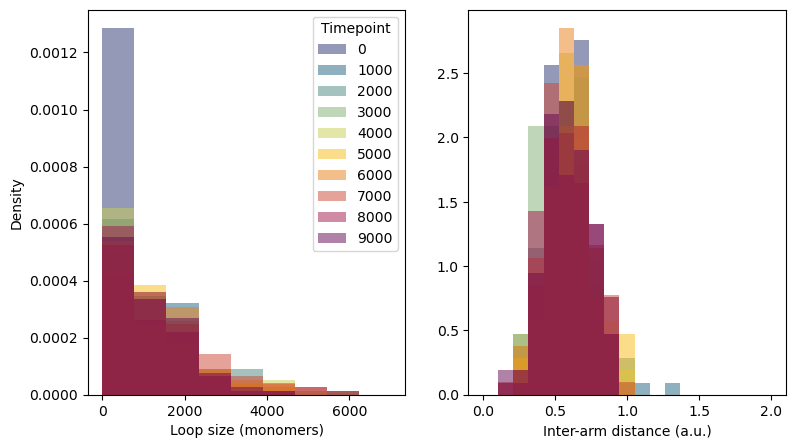

In [60]:
# Lets plot the data as a function of time
colors = cmr.take_cmap_colors('cmr.pride', len(timepoints), cmap_range=(0.1, 0.9))
fig, axs = plt.subplots(1, 2, figsize=(9, 5),)

for idx_timepoint in range(len(timepoints)):
    curr_loop_sizes = loop_size_list[idx_timepoint]
    curr_cohesin_arm_dists = cohesin_arm_dist_list[idx_timepoint]

    loop_size_bins = np.linspace(0, 7000, 10)
    cohesin_arm_dist_bins = np.linspace(0, 2, 20)

    # Plot loop size on the left 
    axs[0].hist(curr_loop_sizes, loop_size_bins, color=colors[idx_timepoint], alpha=0.5, label=timepoints[idx_timepoint], density=True)

    # Plot the inter-arm distance on the right
    axs[1].hist(curr_cohesin_arm_dists, cohesin_arm_dist_bins, color=colors[idx_timepoint], alpha=0.5, label=timepoints[idx_timepoint], density=True)

axs[0].legend(title='Timepoint')
axs[0].set_ylabel('Density')
axs[0].set_xlabel('Loop size (monomers)')
axs[1].set_xlabel('Inter-arm distance (a.u.)')

## For fun: plot the distribution of MD runtime

In [28]:
# For fun: plot the MD runtime for all trajectories
import json
import pandas as pd

data_list =  []
for simulation_folder in simulation_folders:
    json_fpaths = list(simulation_folder.glob('**/runtime_MD_log.json'))
    for json_fpath in json_fpaths:
        with open(json_fpath, "r") as f:
            data = json.load(f)
        data_list.append(data)

data_list_df = pd.DataFrame(data_list)

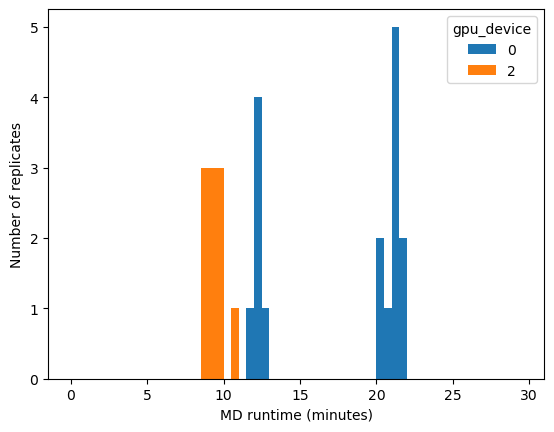

In [30]:
xbins = np.arange(0, 30, 0.5)
for gpu_device in data_list_df['GPU_device'].unique():
    curr_gpu_runtime = data_list_df['runtime'][data_list_df["GPU_device"] == gpu_device]
    plt.hist(curr_gpu_runtime/60, bins=xbins, label=gpu_device)
plt.xlabel('MD runtime (minutes)')
plt.ylabel('Number of replicates')
plt.legend(title='gpu_device')
